In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("../data/raw/bp_readings.csv", sep=";")
df = df.dropna(axis=1, how="all")

In [30]:
df.head()

,date,period,time,systolic,diastolic
0,2026-02-27,morning,07:00,129,69
1,2026-02-27,night,18:00,146,84
2,2026-02-27,night,20:00,125,62
3,2026-02-28,morning,07:00,132,80
4,2026-02-28,night,22:00,142,77


In [ ]:
# Retorna um objeto chamado Index, uma estrutura que guarda os rótulos das colunas.
df.columns

Index(['date', 'period', 'time', 'systolic', 'diastolic'], dtype='str')

In [ ]:
# Retorna os tipos das colunas
df.dtypes

date         datetime64[us]
period             category
time                    str
systolic              int64
diastolic             int64
timestamp    datetime64[us]
dtype: object

In [40]:
df["date"] = pd.to_datetime(df["date"])
df["period"] = df["period"].astype("category")
df["systolic"] = df["systolic"].astype(int)
df["diastolic"] = df["diastolic"].astype(int)

In [34]:
df["timestamp"] = pd.to_datetime(
    df["date"].astype(str) + " " + df["time"]
)

In [42]:
df.dtypes

date         datetime64[us]
period             category
time                    str
systolic              int64
diastolic             int64
timestamp    datetime64[us]
dtype: object

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       22 non-null     datetime64[us]
 1   period     22 non-null     str           
 2   time       22 non-null     str           
 3   systolic   22 non-null     int64         
 4   diastolic  22 non-null     int64         
 5   timestamp  22 non-null     datetime64[us]
dtypes: datetime64[us](2), int64(2), str(2)
memory usage: 1.2 KB


In [38]:
df.describe()

,date,systolic,diastolic,timestamp
count,22,22.000000,22.000000,22
mean,2026-03-03 19:38:10.909091,124.500000,61.909091,2026-03-04 09:55:13.636363
min,2026-02-27 00:00:00,108.000000,36.000000,2026-02-27 07:00:00
25%,2026-03-01 00:00:00,116.000000,56.250000,2026-03-01 11:56:15
50%,2026-03-03 12:00:00,126.000000,62.500000,2026-03-04 01:45:00
75%,2026-03-06 18:00:00,129.750000,64.750000,2026-03-07 04:40:00
max,2026-03-10 00:00:00,146.000000,84.000000,2026-03-10 08:30:00
std,NaN,10.107753,10.783184,NaN


In [ ]:
# Conta quantos valores faltantes existem em cada coluna.
df.isna().sum()

date         0
period       0
time         0
systolic     0
diastolic    0
timestamp    0
dtype: int64

In [43]:
df.nunique()

date         12
period        2
time         16
systolic     18
diastolic    15
timestamp    22
dtype: int64

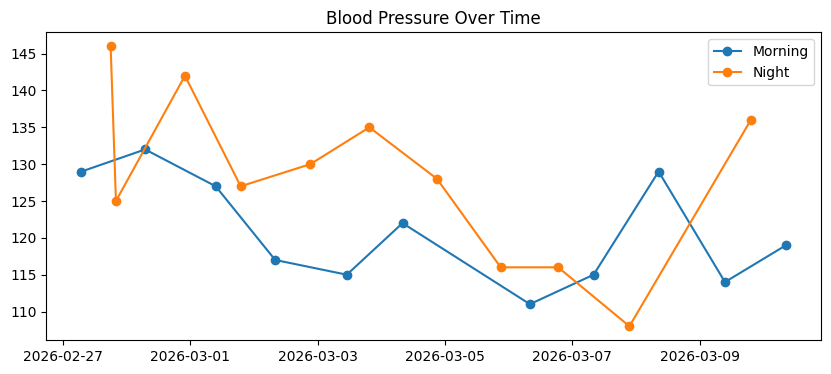

In [27]:
plt.figure(figsize=(10,4))

morning = df[df["period"] == "morning"]
night = df[df["period"] == "night"]

plt.plot(morning["timestamp"], morning["systolic"], marker="o", label="Morning")
plt.plot(night["timestamp"], night["systolic"], marker="o", label="Night")

plt.title("Blood Pressure Over Time")
plt.legend()

plt.show()